In [1]:
import numpy as np
import pandas as pd
import os
import imghdr
import pickle

In [2]:
import cv2 as cv
import matplotlib.pyplot as plt
from skimage.feature import greycomatrix, greycoprops

In [3]:
import skimage
import skimage.feature

In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

In [5]:
with open('C:/Users/eciom/Machine Learning/Projecto IA 2/Normalization/split_dataset.pkl', 'rb') as f:
    train, validation, test = pickle.load(f)
    
with open('C:/Users/eciom/Machine Learning/Projecto IA 2/Normalization/padronizacao.pkl', 'rb') as f:
    x, y = pickle.load(f)

with open('C:/Users/eciom/Machine Learning/Projecto IA 2/Normalization/normalizacao.pkl', 'rb') as f:
    x_2, y_2 = pickle.load(f)

with open('C:/Users/eciom/Machine Learning/Projecto IA 2/Normalization/Temp/temp_padronizacao.pkl', 'rb') as f:
    temp = pickle.load(f)

with open('C:/Users/eciom/Machine Learning/Projecto IA 2/Normalization/Temp/temp_normalizacao.pkl', 'rb') as f:
    temp_2 = pickle.load(f)

with open('C:/Users/eciom/Machine Learning/Projecto IA 2/Normalization/split_dataset.pkl', 'rb') as f:
    train, validation, test = pickle.load(f)

with open('C:/Users/eciom/Machine Learning/Projecto IA 2/Normalization/Data Normalization/data_normalization.pkl', 'rb') as f:
    data_normalization = pickle.load(f)
    
with open('C:/Users/eciom/Machine Learning/Projecto IA 2/Normalization/Data Normalization/data_normalization_2.pkl', 'rb') as f:
    data_normalization_2 = pickle.load(f)

# 1. Processamento de imagens

In [4]:
def glcm_feature(matrix_coocurrence, featureName):
    feature = greycoprops(matrix_coocurrence, featureName)
    result = np.average(feature)
    return result

In [5]:
def processamentoImagem (image):
    test_img = cv.cvtColor (image, cv.COLOR_BGR2RGB)
    test_img_gray = cv.cvtColor (test_img, cv.COLOR_RGB2GRAY)
    test_img_thresh = cv.adaptiveThreshold(test_img_gray,255,cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY_INV,11,3)
    cnts = cv.findContours(test_img_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]
    cnts = sorted(cnts, key=cv.contourArea, reverse=True)
    
    for c in cnts:
        x,y,w,h = cv.boundingRect(c)
        test_img_ROI = test_img[y:y+h, x:x+w]
        break
    test_img_ROI_resize = cv.resize(test_img_ROI, (width, height))
    test_img_ROI_resize_gray = cv.cvtColor(test_img_ROI_resize, cv.COLOR_RGB2GRAY)
    
    return test_img_ROI_resize_gray

## 1.1. Extração de Features

In [6]:
file_normal = 300
file_cataract = 100
file_glaucoma = 101
file_retina = 100
width, height = 400, 400
distance = 10
teta = 90
data_eye = np.zeros((5, 601))
count = 0

indextable = ['contrast', 'homogenity', 'energy', 'correlation', 'Label']

normal_dataset_path = 'C:/Users/eciom/Machine Learning/Projecto IA 2/dataset/1_normal/'
cataract_dataset_path = 'C:/Users/eciom/Machine Learning/Projecto IA 2/dataset/2_cataract/'
glaucoma_dataset_path = 'C:/Users/eciom/Machine Learning/Projecto IA 2/dataset/3_glaucoma/'
retina_dataset_path = 'C:/Users/eciom/Machine Learning/Projecto IA 2/dataset/4_retina_disease/'

 ### 1.1.1. Extração dos dados das imagens da retina normal

In [8]:
for file in range(1, file_normal):
    contrast = []
    homogeneity = []
    energy = []
    correlation = []
    label = 0
    image = cv.imread(f'{normal_dataset_path}/NL_{str(file).zfill(3)}.png')
    img = processamentoImagem(image)
    
    glcm = skimage.feature.greycomatrix(img, [distance], [teta], levels=256, symmetric=True, normed=True)
    contrast.append(glcm_feature(glcm, 'contrast'))
    homogeneity.append(glcm_feature(glcm, 'homogeneity'))
    energy.append(glcm_feature(glcm, 'energy'))
    correlation.append(glcm_feature(glcm, 'correlation'))
    
    data_eye[0, count] = contrast[0]
    data_eye[1, count] = homogeneity[0]
    data_eye[2, count] = energy[0]
    data_eye[3, count] = correlation[0]
    data_eye[4, count] = label
    
    count += 1

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

...

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

In [9]:
data_eye

array([[2.04125636e+02, 3.35220717e+02, 3.01578832e+02, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [3.13721489e-01, 2.77447240e-01, 3.18182124e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [9.69602830e-02, 9.36831196e-02, 1.04448580e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [8.94945022e-01, 9.12147749e-01, 8.87562327e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

### 1.1.2. Extração dos dados das imagens da retina do olho com catarata

In [10]:
for file in range(1, file_cataract):
    contrast = []
    homogeneity = []
    energy = []
    correlation = []
    label = 1
    image = cv.imread(f'{cataract_dataset_path}/cataract_{str(file).zfill(3)}.png')
    img = processamentoImagem(image)
    
    glcm = skimage.feature.greycomatrix(img, [distance], [teta], levels=256, symmetric=True, normed=True)
    contrast.append(glcm_feature(glcm, 'contrast'))
    homogeneity.append(glcm_feature(glcm, 'homogeneity'))
    energy.append(glcm_feature(glcm, 'energy'))
    correlation.append(glcm_feature(glcm, 'correlation'))
    
    data_eye[0, count] = contrast[0]
    data_eye[1, count] = homogeneity[0]
    data_eye[2, count] = energy[0]
    data_eye[3, count] = correlation[0]
    data_eye[4, count] = label
    
    count += 1

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

...

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

### 1.1.3. Extração dos dados das imagens da retina do olho com glaucoma

In [11]:
for file in range(1, file_glaucoma):
    contrast = []
    homogeneity = []
    energy = []
    correlation = []
    label = 2
    image = cv.imread(f'{glaucoma_dataset_path}/Glaucoma_{str(file).zfill(3)}.png')
    img = processamentoImagem(image)
    
    glcm = greycomatrix(img, [distance], [teta], levels=256, symmetric=True, normed=True)
    contrast.append(glcm_feature(glcm, 'contrast'))
    homogeneity.append(glcm_feature(glcm, 'homogeneity'))
    energy.append(glcm_feature(glcm, 'energy'))
    correlation.append(glcm_feature(glcm, 'correlation'))
    
    data_eye[0, count] = contrast[0]
    data_eye[1, count] = homogeneity[0]
    data_eye[2, count] = energy[0]
    data_eye[3, count] = correlation[0]
    data_eye[4, count] = label
    
    count += 1

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

...

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

### 1.1.4. Extração dos dados da imagens da retina do olho com doenças de retina

In [12]:
for file in range(1, file_retina):
    contrast = []
    homogeneity = []
    energy = []
    correlation = []
    label = 3
    image = cv.imread(f'{retina_dataset_path}/Retina_{str(file).zfill(3)}.png')
    img = processamentoImagem(image)
    
    glcm = skimage.feature.greycomatrix(img, [distance], [teta], levels=256, symmetric=True, normed=True)
    contrast.append(glcm_feature(glcm, 'contrast'))
    homogeneity.append(glcm_feature(glcm, 'homogeneity'))
    energy.append(glcm_feature(glcm, 'energy'))
    correlation.append(glcm_feature(glcm, 'correlation'))
    
    data_eye[0, count] = contrast[0]
    data_eye[1, count] = homogeneity[0]
    data_eye[2, count] = energy[0]
    data_eye[3, count] = correlation[0]
    data_eye[4, count] = label
    
    count += 1

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

...

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:35: skimage_deprecation: Function ``greycomatrix`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycomatrix`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-packages\skimage\feature\__init__.py:42: skimage_deprecation: Function ``greycoprops`` is deprecated and will be removed in version 1.0. Use ``skimage.feature.graycoprops`` instead.
  removed_version='1.0')
C:\Users\eciom\anaconda3\lib\site-

### 1.1.5 Compactação dos dados extraído para um tabela

In [13]:
df= pd.DataFrame(np.transpose(data_eye), columns = indextable)

In [14]:
df

,contrast,homogenity,energy,correlation,Label
0,204.125636,0.313721,0.096960,0.894945,0.0
1,335.220717,0.277447,0.093683,0.912148,0.0
2,301.578832,0.318182,0.104449,0.887562,0.0
3,224.192882,0.331177,0.103919,0.914002,0.0
4,576.100074,0.307271,0.112997,0.888428,0.0
...,...,...,...,...,...
596,320.025588,0.258287,0.114448,0.951708,3.0
597,0.000000,0.000000,0.000000,0.000000,0.0
598,0.000000,0.000000,0.000000,0.000000,0.0
599,0.000000,0.000000,0.000000,0.000000,0.0


In [15]:
df.describe()

,contrast,homogenity,energy,correlation,Label
count,601.000000,601.000000,601.000000,601.000000,601.000000
mean,484.406709,0.323896,0.111769,0.890731,0.991681
std,188.779091,0.053096,0.014905,0.076110,1.153949
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,351.971589,0.297593,0.105742,0.883726,0.000000
50%,472.477893,0.313195,0.113031,0.900048,0.000000
75%,590.814759,0.341431,0.119212,0.911589,2.000000
max,1247.978855,0.517782,0.170701,0.951708,3.000000


In [16]:
df.mean()

contrast       484.406709
homogenity       0.323896
energy           0.111769
correlation      0.890731
Label            0.991681
dtype: float64

#### Apagando as tuplas com valores nulos

In [17]:
df.loc[df['contrast'] <= 0]

,contrast,homogenity,energy,correlation,Label
597,0.0,0.0,0.0,0.0,0.0
598,0.0,0.0,0.0,0.0,0.0
599,0.0,0.0,0.0,0.0,0.0
600,0.0,0.0,0.0,0.0,0.0


In [18]:
df2 = df.drop(df[df['contrast'] <= 0].index)

In [19]:
df2

,contrast,homogenity,energy,correlation,Label
0,204.125636,0.313721,0.096960,0.894945,0.0
1,335.220717,0.277447,0.093683,0.912148,0.0
2,301.578832,0.318182,0.104449,0.887562,0.0
3,224.192882,0.331177,0.103919,0.914002,0.0
4,576.100074,0.307271,0.112997,0.888428,0.0
...,...,...,...,...,...
592,515.696602,0.264064,0.113051,0.919626,3.0
593,826.924488,0.312105,0.104945,0.858173,3.0
594,616.965215,0.329957,0.111555,0.909242,3.0
595,434.021055,0.336861,0.115360,0.912927,3.0


In [20]:
df2.describe()

,contrast,homogenity,energy,correlation,Label
count,597.000000,597.000000,597.000000,597.000000,597.000000
mean,487.652315,0.326066,0.112517,0.896699,0.998325
std,185.179212,0.046144,0.011800,0.021703,1.154941
min,96.840728,0.213335,0.089109,0.807291,0.000000
25%,354.211081,0.297898,0.106006,0.884057,0.000000
50%,475.024788,0.313215,0.113144,0.900214,0.000000
75%,591.621722,0.341463,0.119241,0.911626,2.000000
max,1247.978855,0.517782,0.170701,0.951708,3.000000


## 1.2. Escalonamento dos dados

Os dados serão escalonados de duas formas: 

• 1º Padronização (Standardisation)
    Onde X = (X - média(x)) / desvio padrão

• 2º Normalização (Normalization)
    Onde X = ((X - min(x)) / (max(x) - min(x))


### 1.2.1. Padronização

In [21]:
from sklearn.preprocessing import StandardScaler as sts

In [22]:
features = df2.drop(['Label'], axis='columns')
scaler = sts()
features = scaler.fit_transform(features)

In [23]:
features

array([[-1.53237739, -0.26774373, -1.31952889, -0.08089552],
       [-0.82384745, -1.05450881, -1.59749293,  0.71241246],
       [-1.00567184, -0.17099545, -0.68438289, -0.42135029],
       ...,
       [ 0.69889777,  0.08439532, -0.08166542,  0.57841195],
       [-0.28986101,  0.23414242,  0.24114508,  0.74836667],
       [-0.90597261, -1.47008192,  0.16372235,  2.53674981]])

In [24]:
data_normalization = df2.copy()
data_normalization[['contrast', 'homogenity', 'energy', 'correlation']] = features

In [25]:
data_normalization

,contrast,homogenity,energy,correlation,Label
0,-1.532377,-0.267744,-1.319529,-0.080896,0.0
1,-0.823847,-1.054509,-1.597493,0.712412,0.0
2,-1.005672,-0.170995,-0.684383,-0.421350,0.0
3,-1.423920,0.110853,-0.729339,0.797912,0.0
4,0.478034,-0.407649,0.040650,-0.381421,0.0
...,...,...,...,...,...
592,0.151571,-1.344776,0.045266,1.057256,3.0
593,1.833665,-0.302798,-0.642236,-1.776637,3.0
594,0.698898,0.084395,-0.081665,0.578412,3.0
595,-0.289861,0.234142,0.241145,0.748367,3.0


In [26]:
data_normalization.describe()

,contrast,homogenity,energy,correlation,Label
count,5.970000e+02,5.970000e+02,5.970000e+02,5.970000e+02,597.000000
mean,3.713761e-16,7.665560e-16,1.674633e-15,-3.832408e-15,0.998325
std,1.000839e+00,1.000839e+00,1.000839e+00,1.000839e+00,1.154941
min,-2.112220e+00,-2.445055e+00,-1.985476e+00,-4.123101e+00,0.000000
25%,-7.212102e-01,-6.109410e-01,-5.522702e-01,-5.830110e-01,0.000000
50%,-6.824803e-02,-2.787192e-01,5.315169e-02,1.620856e-01,0.000000
75%,5.619237e-01,3.339456e-01,5.702941e-01,6.883646e-01,2.000000
max,4.109339e+00,4.158194e+00,4.935082e+00,2.536750e+00,3.000000


In [27]:
x = data_normalization.drop(['Label'], axis='columns')
y = data_normalization.Label

In [69]:
with open ('C:/Users/eciom/Machine Learning/Projecto IA 2/Normalization/padronizacao.pkl',
           mode='wb') as f:
    pickle.dump([x, y], f)

In [29]:
temp = scaler.fit_transform(df2)s

In [30]:
temp

array([[-1.53237739, -0.26774373, -1.31952889, -0.08089552, -0.86511927],
       [-0.82384745, -1.05450881, -1.59749293,  0.71241246, -0.86511927],
       [-1.00567184, -0.17099545, -0.68438289, -0.42135029, -0.86511927],
       ...,
       [ 0.69889777,  0.08439532, -0.08166542,  0.57841195,  1.73459317],
       [-0.28986101,  0.23414242,  0.24114508,  0.74836667,  1.73459317],
       [-0.90597261, -1.47008192,  0.16372235,  2.53674981,  1.73459317]])

In [70]:
with open ('C:/Users/eciom/Machine Learning/Projecto IA 2/Normalization/temp_padronizacao.pkl',
           mode='wb') as f:
    pickle.dump([temp], f)

In [71]:
with open ('C:/Users/eciom/Machine Learning/Projecto IA 2/Normalization/data_normalization.pkl',
           mode='wb') as f:
    pickle.dump([data_normalization], f)

### 1.2.2. Normalização

In [35]:
from sklearn.preprocessing import MinMaxScaler

In [36]:
features_2 = df.drop(['Label'], axis='columns')
scaler_2 = MinMaxScaler()
features_2 = scaler_2.fit_transform(features_2)

In [37]:
features_2

array([[0.16356498, 0.6058951 , 0.56801101, 0.94035658],
       [0.2686109 , 0.53583809, 0.54881279, 0.95843222],
       [0.2416538 , 0.61450999, 0.61187882, 0.93259927],
       ...,
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        ]])

In [38]:
data_normalization_2 = df.copy()

In [39]:
data_normalization_2[['contrast', 'homogenity', 'energy', 'correlation']] = features_2
data_normalization_2

,contrast,homogenity,energy,correlation,Label
0,0.163565,0.605895,0.568011,0.940357,0.0
1,0.268611,0.535838,0.548813,0.958432,0.0
2,0.241654,0.614510,0.611879,0.932599,0.0
3,0.179645,0.639607,0.608774,0.960380,0.0
4,0.461626,0.593437,0.661955,0.933509,0.0
...,...,...,...,...,...
596,0.256435,0.498834,0.670455,1.000000,3.0
597,0.000000,0.000000,0.000000,0.000000,0.0
598,0.000000,0.000000,0.000000,0.000000,0.0
599,0.000000,0.000000,0.000000,0.000000,0.0


In [40]:
data_normalization_2.drop(data_normalization_2[data_normalization_2['contrast'] <= 0].index)

,contrast,homogenity,energy,correlation,Label
0,0.163565,0.605895,0.568011,0.940357,0.0
1,0.268611,0.535838,0.548813,0.958432,0.0
2,0.241654,0.614510,0.611879,0.932599,0.0
3,0.179645,0.639607,0.608774,0.960380,0.0
4,0.461626,0.593437,0.661955,0.933509,0.0
...,...,...,...,...,...
592,0.413225,0.509991,0.662274,0.966290,3.0
593,0.662611,0.602774,0.614790,0.901719,3.0
594,0.494372,0.637251,0.653507,0.955379,3.0
595,0.347779,0.650585,0.675803,0.959251,3.0


In [41]:
x_2 = data_normalization_2.drop(['Label'], axis='columns')
y_2 = data_normalization_2.Label

In [107]:
with open ('C:/Users/eciom/Machine Learning/Projecto IA 2/Normalization/normalizacao.pkl',
           mode='wb') as f:
    pickle.dump([x_2, y_2], f)

In [42]:
temp_2 = scaler_2.fit_transform(data_normalization_2)

In [43]:
temp_2

array([[0.16356498, 0.6058951 , 0.56801101, 0.94035658, 0.        ],
       [0.2686109 , 0.53583809, 0.54881279, 0.95843222, 0.        ],
       [0.2416538 , 0.61450999, 0.61187882, 0.93259927, 0.        ],
       ...,
       [0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ]])

In [44]:
with open ('C:/Users/eciom/Machine Learning/Projecto IA 2/Normalization/Temp/temp_normalizacao.pkl',
           mode='wb') as f:
    pickle.dump([temp_2], f)

In [ ]:
with open ('C:/Users/eciom/Machine Learning/Projecto IA 2/Normalization/data_normalization_2.pkl',
           mode='wb') as f:
    pickle.dump([data_normalization_2], f)

# 2. Divisão do dataset

Os dados foram separados nas seguintes percentagens:
    • 60% - Train set
    • 20% - Validation set
    • 20% - Test set

In [7]:
from sklearn.model_selection import train_test_split 

## 2.1. Padronização

Divide os dados padronizados em treinamento e teste

In [8]:
train_features, test_features, train_labels, test_labels = train_test_split(x, y, test_size=0.2, random_state=42)

Divide os dados de treinamento em treinamento e validação

In [9]:
train_features, validation_features, train_labels, validation_labels = train_test_split(train_features, train_labels, test_size=0.2, random_state=42)

## 2.2. Normalização

Divide os dados normalizados em treinamento e teste

In [10]:
train_features_2, test_features_2, train_labels_2, test_labels_2 = train_test_split(x_2, y_2, test_size=0.2, random_state=42)

Divide os dados de treinamento em treinamento e validação

In [11]:
train_features_2, validation_features_2, train_labels_2, validation_labels_2 = train_test_split(train_features_2, train_labels_2, test_size=0.2, random_state=42)

# 3. Modelo

## 3.1. Random Forest

### 3.1. Padronização

In [12]:
from sklearn.ensemble import RandomForestClassifier

In [13]:
from sklearn.metrics import accuracy_score, classification_report
from yellowbrick.classifier import ConfusionMatrix

In [41]:
random_forest = RandomForestClassifier(n_estimators = 10, criterion='entropy', random_state=0)

Treinamento do modelo Random Forest

In [42]:
random_forest.fit(train_features, train_labels)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

Avaliação do modelo no conjunto de validação

In [43]:
accuracy = random_forest.score(validation_features, validation_labels)
accuracy

0.53125

In [44]:
prediction_1 = random_forest.predict(test_features)
accuracy_score(test_labels, prediction_1) 

0.575

C:\Users\eciom\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


0.53125

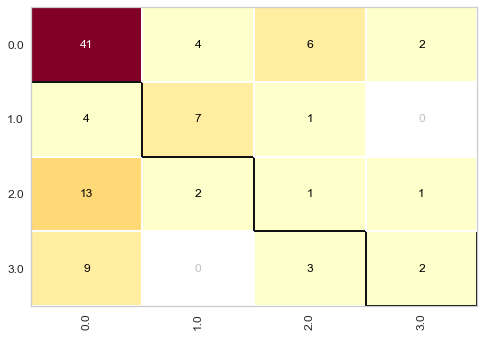

In [45]:
cm = ConfusionMatrix (random_forest)
cm.fit(train_features, train_labels)
cm.score(validation_features, validation_labels)

C:\Users\eciom\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


0.575

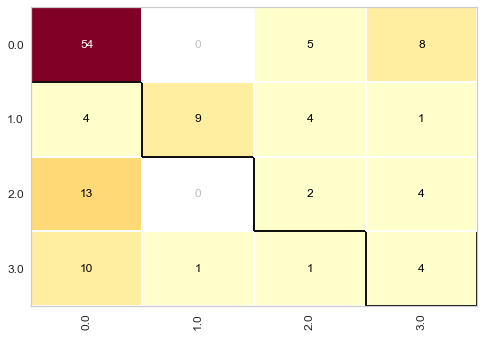

In [46]:
cm = ConfusionMatrix (random_forest)
cm.fit(train_features, train_labels)
cm.score(test_features, test_labels)

### 3.2. Normalização

In [65]:
random_forest = RandomForestClassifier(n_estimators = 10, criterion='entropy', random_state=0)

Treinamento do modelo Random Forest

In [66]:
random_forest.fit(train_features_2, train_labels_2)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)


Avaliação do modelo no conjunto de validação

In [67]:
accuracy = random_forest.score(validation_features_2, validation_labels_2)
accuracy

0.5729166666666666

In [68]:
prediction_1_1 = random_forest.predict(test_features_2)
accuracy_score(test_labels_2, prediction_1_1) 

0.5619834710743802

C:\Users\eciom\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


0.5729166666666666

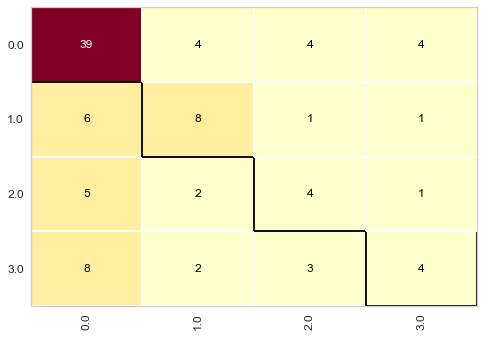

In [69]:
cm = ConfusionMatrix (random_forest)
cm.fit(train_features_2, train_labels_2)
cm.score(validation_features_2, validation_labels_2)

C:\Users\eciom\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


0.5619834710743802

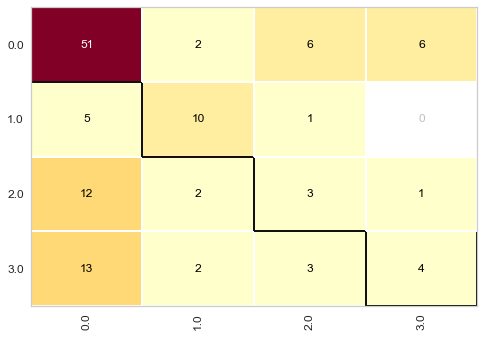

In [70]:
cm = ConfusionMatrix (random_forest)
cm.fit(train_features_2, train_labels_2)
cm.score(test_features_2, test_labels_2)

## 3.2. Support Vector Machines (SVM)

### 3.2.1. Padronização

In [71]:
from sklearn.svm import SVC

In [90]:
svm_model = SVC(kernel='rbf', random_state=1, C = 1.0)

Treinando o modelo

In [91]:
svm_model.fit(train_features, train_labels)

SVC(random_state=1)

In [92]:
#Avaliação do modelo
accuracy = svm_model.score(validation_features, validation_labels)
accuracy

0.6354166666666666

In [93]:
# Fazendo previsões
prediction_2 = svm_model.predict(test_features)
accuracy_score(test_labels, prediction_2) 

0.65

C:\Users\eciom\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


0.6354166666666666

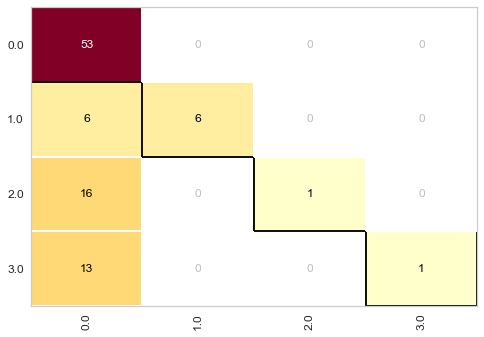

In [94]:
cm = ConfusionMatrix (svm_model)
cm.fit(train_features, train_labels)
cm.score(validation_features, validation_labels)

C:\Users\eciom\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


0.65

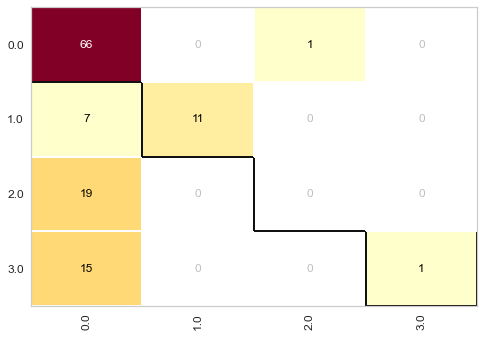

In [95]:
cm = ConfusionMatrix (svm_model)
cm.fit(train_features, train_labels)
cm.score(test_features, test_labels)

### 3.2.2. Normalização

In [119]:
svm_model = SVC(kernel='rbf', random_state=1, C = 1.0)

In [120]:
# Treinando o modelo
svm_model.fit(train_features_2, train_labels_2)

SVC(random_state=1)

In [121]:
#Avaliação do modelo
accuracy = svm_model.score(validation_features_2, validation_labels_2)
accuracy

0.6145833333333334

In [122]:
# Fazendo previsões
prediction_2 = svm_model.predict(test_features_2)
accuracy_score(test_labels_2, prediction_2) 

0.6198347107438017

C:\Users\eciom\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


0.6145833333333334

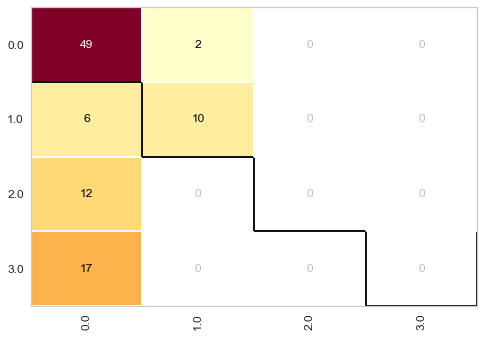

In [123]:
cm = ConfusionMatrix (svm_model)
cm.fit(train_features_2, train_labels_2)
cm.score(validation_features_2, validation_labels_2)

C:\Users\eciom\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


0.6198347107438017

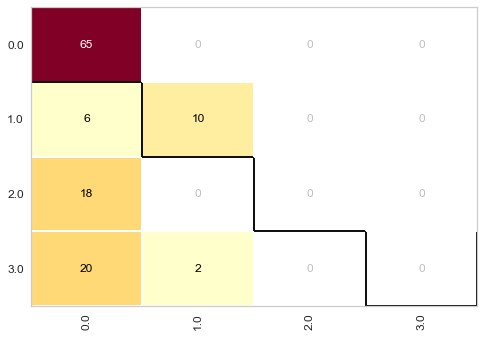

In [124]:
cm = ConfusionMatrix (svm_model)
cm.fit(train_features_2, train_labels_2)
cm.score(test_features_2, test_labels_2)

## 3.3. Redes Neurais Convulucionais (CNN)

In [5]:
#Estabelecer o conjunto de dados(sem os rotulos que serao criados posteriormente)
data = tf.keras.utils.image_dataset_from_directory('dataset')
class_names = data.class_names

Found 601 files belonging to 4 classes.


In [6]:
class_names

['1_normal', '2_cataract', '2_glaucoma', '3_retina_disease']

In [7]:
#Garantir o acesso ao pipiline dos dados
data_count = data.as_numpy_iterator()

In [8]:
#batch e composto pelas imagens e rotulos
batch = data_count.next()

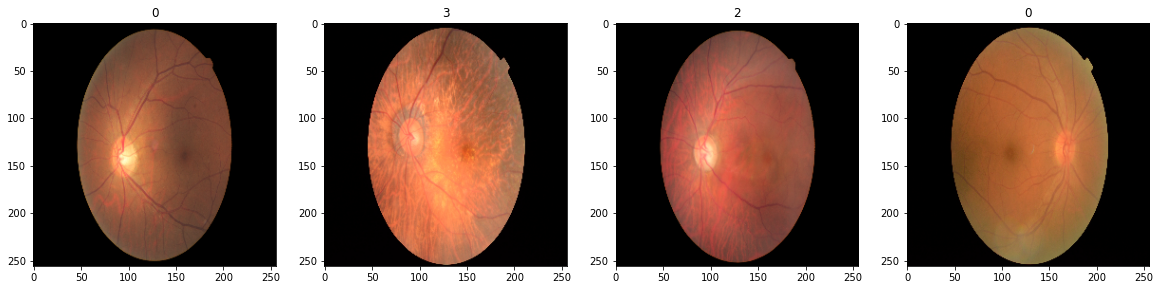

In [9]:
#Batches(normal, cataracta, glaucoma, retina)

fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for index, img in enumerate(batch[0][:4]):
    ax[index].imshow(img.astype(int))
    ax[index].title.set_text(batch[1][index])

### 3.3.1. Pré Processamento

Normalizacao da escala dos pixels das imagens para [0,1]

x - imagens

y - labels

In [10]:
data = data.map(lambda x,y: (x/255, y))

In [11]:
data.as_numpy_iterator().next()

(array([[[[0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
          [1.1795344e-03, 1.7156863e-03, 1.7156863e-03],
          ...,
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
          [1.6850491e-04, 0.0000000e+00, 0.0000000e+00],
          [6.6176471e-03, 3.5386030e-03, 3.9215689e-03]],
 
         [[0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
          [3.9215689e-03, 0.0000000e+00, 0.0000000e+00],
          [7.4601714e-03, 2.2058825e-03, 2.2058825e-03],
          ...,
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
          [2.4509805e-04, 0.0000000e+00, 0.0000000e+00],
          [0.0000000e+00, 3.6764706e-03, 3.6764706e-03]],
 
         [[0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
          [3.9215689e-03, 2.6807599e-03, 2.6807599e-03],
          ...,
          [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
          [1.7156863e-03, 0.0000000e+

### 3.3.2. Divisão do Dataset

In [12]:
#Dividir os dados em: 70% para treino, 20% para validacao, e 10% para teste
train_size = int(len(data)*0.7)
val_size = int(len(data)*0.2)
test_size = int(len(data)*0.1)

In [13]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

### 3.3.3. Criacao do Modelo

In [14]:
train

<TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [15]:
model = Sequential()

In [16]:
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D())
model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(4, activation='softmax'))

In [17]:
#accuracy = (número de exemplos classificados corretamente) / (número total de exemplos)
from keras.losses import SparseCategoricalCrossentropy
model.compile(optimizer='adam', loss=SparseCategoricalCrossentropy(), metrics=['accuracy'])

In [18]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 16)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 32)      4640      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 16)        4624      
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 30, 30, 16)       0

In [19]:
logdir='logs'

In [20]:
#Salvar o modelo neste ponto
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [21]:
#Treinamento e validacao
history = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
13/13 [==============================] - 31s 2s/step - loss: 1.3409 - accuracy: 0.4663 - val_loss: 1.3535 - val_accuracy: 0.4479
Epoch 2/20
13/13 [==============================] - 28s 2s/step - loss: 1.2540 - accuracy: 0.5000 - val_loss: 1.2113 - val_accuracy: 0.5208
Epoch 3/20
13/13 [==============================] - 27s 2s/step - loss: 1.2333 - accuracy: 0.5072 - val_loss: 1.3107 - val_accuracy: 0.4062
Epoch 4/20
13/13 [==============================] - 26s 2s/step - loss: 1.2170 - accuracy: 0.5264 - val_loss: 1.2045 - val_accuracy: 0.5000
Epoch 5/20
13/13 [==============================] - 29s 2s/step - loss: 1.1957 - accuracy: 0.5168 - val_loss: 1.1694 - val_accuracy: 0.5417
Epoch 6/20
13/13 [==============================] - 21s 1s/step - loss: 1.0992 - accuracy: 0.5938 - val_loss: 1.2224 - val_accuracy: 0.5625
Epoch 7/20
13/13 [==============================] - 27s 2s/step - loss: 1.1183 - accuracy: 0.5625 - val_loss: 0.9827 - val_accuracy: 0.6875
Epoch 8/20
13/13 [==

In [22]:
# Acurácia final de treinamento
train_accuracy = history.history['accuracy'][-1]

# Acurácia final de validação
val_accuracy = history.history['val_accuracy'][-1]

print("Acurácia final de treinamento:", train_accuracy)
print("Acurácia final de validação:", val_accuracy)

Acurácia final de treinamento: 0.7163461446762085
Acurácia final de validação: 0.6458333134651184


In [23]:
accuracy = model.evaluate(test)

1/1 [==============================] - 8s 8s/step - loss: 0.6237 - accuracy: 0.7188


# Testando o Modelo em Imagens aleatoria

In [24]:
import cv2

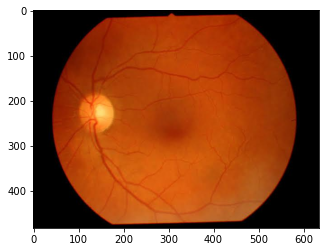

In [25]:
img = cv2.imread('./doenca de retina.jpg')
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.show()

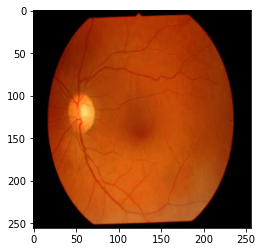

In [26]:
#Aplicar Normalizacao na imagem para prever no modelo
resize = tf.image.resize(img, (256,256))
#final_resize = resize.numpy().astype(int)
final_resize = resize.numpy().astype('uint8')
final_resize = cv2.cvtColor(final_resize, cv2.COLOR_BGR2RGB)
plt.imshow(final_resize)
plt.show()

In [27]:
predicted = model.predict(np.expand_dims(resize/255, 0))

1/1 [==============================] - 0s 105ms/step


In [28]:
predicted


array([[1.2153232e-01, 7.4974430e-01, 6.5334068e-05, 1.2865798e-01]],
      dtype=float32)

In [29]:
predicted_class = np.argmax(predicted)

In [30]:

if predicted_class == 0:
    print("Normal")
elif predicted_class == 1:
    print("Cataracta")
elif predicted_class == 2:
    print("Glaucoma")
else:
    print("Doenca de Retina")

Cataracta
